*Which features earn a place in the model?* This notebook renders the permutation-importance selector (measured against a synthetic noise-decoy column) that freezes the feature set before Optuna hyperparameter tuning, plus a non-gating SHAP audit of the result.

Per the project's `src`-first workflow, the selector itself lives in `src/telco_churn/features/select.py` and the orchestration in `src/telco_churn/models/train/feature_freeze.py`'s `run_selection_step` — both already ran (via `python -m telco_churn.models.train`) and logged every result to MLflow. This notebook **loads and renders** those results: permutation-importance ranking vs. the decoy floor $\rightarrow$ full-set vs. reduced-set paired-bootstrap test $\rightarrow$ SHAP audit.

In [1]:
%matplotlib inline

from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

from telco_churn.features.select import DEFAULT_CORRELATED_GROUPS
from telco_churn.data.eda import encoded_correlation_matrix
from telco_churn.data.split import partition
from telco_churn.features.build import FEATURE_SCHEMA, TARGET_COL
from telco_churn.utils.logging import configure_logging
from telco_churn.utils.paths import compose_config, get_project_root

configure_logging()
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

## 1. Load results from MLflow

In [2]:
cfg = compose_config()

tracking_uri = str(cfg.mlflow.tracking_uri)
if "://" not in tracking_uri:
    tracking_uri = str(get_project_root() / tracking_uri)
mlflow.set_tracking_uri(tracking_uri)

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(cfg.mlflow.experiment_name)
# lifecycle_stage check is required: the MLflow UI hides deleted experiments,
# but get_experiment_by_name still returns them for reads.
if exp is None or exp.lifecycle_stage != "active":
    raise RuntimeError(
        f"No active MLflow experiment named '{cfg.mlflow.experiment_name}' found "
        f"(tracking_uri={tracking_uri}). Run `python -m telco_churn.models.train` first."
    )


def latest_run(run_name: str):
    runs = client.search_runs(
        [exp.experiment_id],
        filter_string=f"attributes.run_name = '{run_name}'",
        order_by=["start_time DESC"],
        max_results=1,
    )
    if not runs:
        raise RuntimeError(
            f"No '{run_name}' run found in experiment '{cfg.mlflow.experiment_name}'. "
            "Run `python -m telco_churn.models.train` first."
        )
    return runs[0]


run_ids = {
    name: latest_run(name).info.run_id
    for name in ("lgbm_default", "feature_selection")
}
for name, run_id in run_ids.items():
    print(f"{name:<18} {run_id}")

lgbm_default       ca928fb76d2047a48a5d57fbd2b7ca01
feature_selection  bb33d2a9328043579ef192efbe8b8772


### Validate: `feature_selection` was built on this `lgbm_default` run

`run_selection_step` reuses `candidate_results["lgbm_default"]["pr_auc_scores"]` in-process rather than re-reading MLflow, so the full-set numbers logged on the `feature_selection` run only match the `lgbm_default` run above if both came from the same `python -m telco_churn.models.train` execution — pulling "latest" of each independently doesn't guarantee that. Cross-check `git_sha`, `dvc_data_hash`, and the CV PR-AUC itself before trusting the pairing used below.

In [3]:
lgbm_run = client.get_run(run_ids["lgbm_default"])
selection_run = client.get_run(run_ids["feature_selection"])

assert lgbm_run.data.tags["git_sha"] == selection_run.data.tags["git_sha"], (
    "lgbm_default and feature_selection runs come from different git commits - "
    "'latest' pulled a stale pairing across the two run names."
)
assert lgbm_run.data.tags["dvc_data_hash"] == selection_run.data.tags["dvc_data_hash"], (
    "lgbm_default and feature_selection runs were trained on different data snapshots."
)

lgbm_cv_pr_auc = lgbm_run.data.metrics["cv_pr_auc_mean"]
full_cv_pr_auc = selection_run.data.metrics["full_cv_pr_auc_mean"]
assert abs(lgbm_cv_pr_auc - full_cv_pr_auc) < 1e-9, (
    f"feature_selection's full-set CV PR-AUC ({full_cv_pr_auc:.6f}) does not match "
    f"the latest lgbm_default run's CV PR-AUC ({lgbm_cv_pr_auc:.6f}) - "
    "the selection step ran against a different lgbm_default fit than the one loaded here."
)

print(
    f"Confirmed: feature_selection was built on this lgbm_default run "
    f"(git_sha={lgbm_run.data.tags['git_sha'][:8]}, full-set CV PR-AUC={lgbm_cv_pr_auc:.4f})"
)

Confirmed: feature_selection was built on this lgbm_default run (git_sha=629c1215, full-set CV PR-AUC=0.6580)


## 2. Permutation-importance ranking

Which individual features actually carry signal on their own, measured against a column of pure noise? This is answered with **grouped permutation importance**: shuffle each source feature's one-hot dummies together (so a categorical's dummies move as one unit, not independently) and measure the resulting mean PR-AUC drop on a held-out split — a signal that is model-agnostic by construction, unlike LightGBM's built-in **gain** importance (how often and how usefully a feature is used to split trees). A synthetic **noise-decoy column** — built to hold no real information — sets the bar: a feature survives only if its real importance exceeds `max(decoy_importance, 0) + noise_floor_margin` (`noise_floor_margin = 0.005`).

Decoy column importance (pure-noise reference for this fit): -0.0060

10 of 20 features individually cleared the decoy floor on the all-dev fit.



feature,real_importance,importance_floor,survived
tenure,0.0880,0.0050,True
contract_type,0.0840,0.0050,True
internetservice,0.0280,0.0050,True
totalcharges,0.0240,0.0050,True
monthlycharges,0.0200,0.0050,True
multiplelines,0.0160,0.0050,True
paymentmethod,0.0130,0.0050,True
techsupport,0.0090,0.0050,True
onlinesecurity,0.0080,0.0050,True
streamingtv,0.0060,0.0050,True

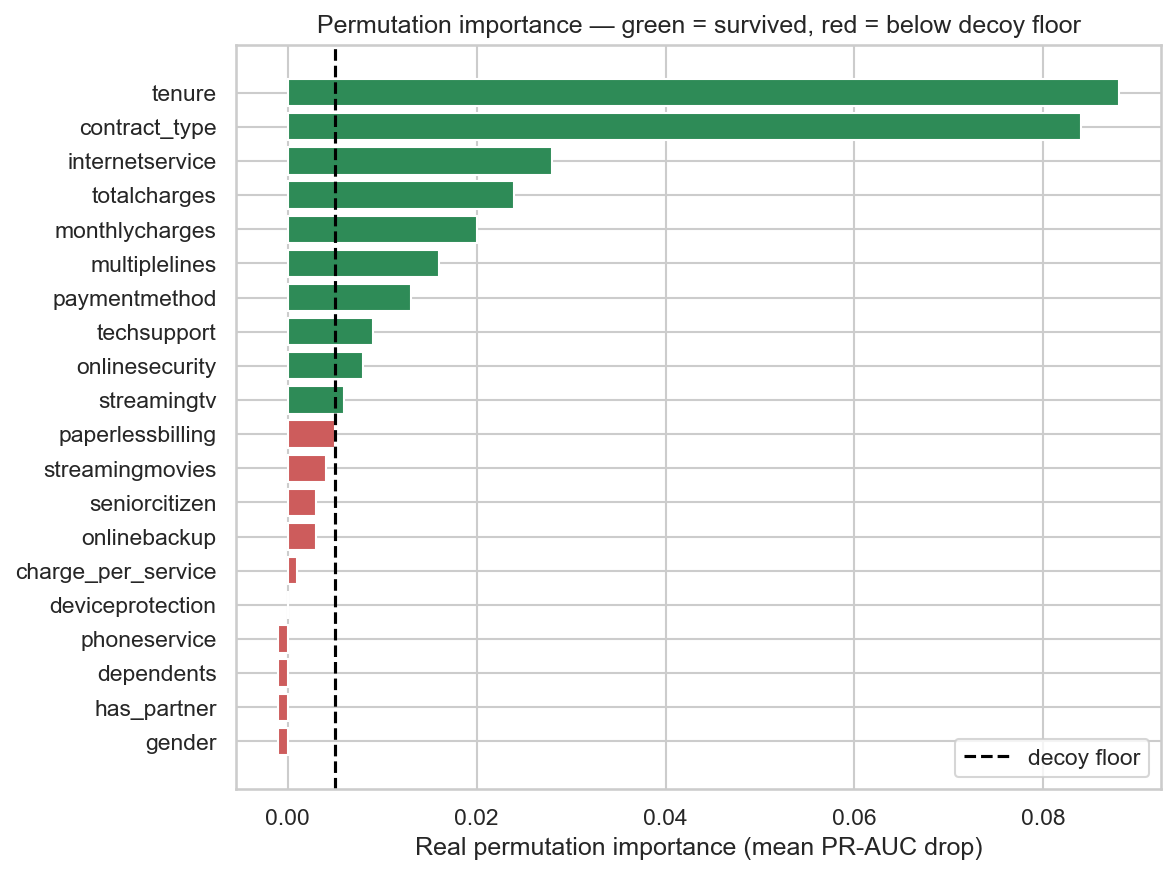

In [4]:
import base64
from io import BytesIO

from IPython.display import HTML

sel_dir = mlflow.artifacts.download_artifacts(run_id=run_ids["feature_selection"], artifact_path="selection")
importance_table = pd.read_csv(f"{sel_dir}/permutation_importance_table.csv").sort_values(
    "real_importance", ascending=False
)

decoy_importance = float(importance_table["decoy_importance"].iloc[0])
print(f"Decoy column importance (pure-noise reference for this fit): {decoy_importance:.4f}\n")

n_survived = int(importance_table["survived"].sum())
n_total = len(importance_table)
print(f"{n_survived} of {n_total} features individually cleared the decoy floor on the all-dev fit.\n")


def _highlight(row):
    style = (
        "background-color: #c6efce; color: #006100"
        if row["survived"]
        else "background-color: #ffc7ce; color: #9c0006"
    )
    return [style] * len(row)


display_table = importance_table[["feature", "real_importance", "importance_floor", "survived"]]
table_html = (
    display_table.style.apply(_highlight, axis=1)
    .format({"real_importance": "{:.4f}", "importance_floor": "{:.4f}"})
    .hide(axis="index")
    .to_html()
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = importance_table["survived"].map({True: "seagreen", False: "indianred"})
ax.barh(importance_table["feature"], importance_table["real_importance"], color=colors)
ax.axvline(importance_table["importance_floor"].iloc[0], color="black", linestyle="--", label="decoy floor")
ax.set_xlabel("Real permutation importance (mean PR-AUC drop)")
ax.set_title("Permutation importance — green = survived, red = below decoy floor")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
plt.close(fig)
chart_b64 = base64.b64encode(buf.getvalue()).decode("ascii")

HTML(
    '<div style="display:flex; align-items:flex-start; gap:24px; flex-wrap:wrap;">'
    f'<div style="flex:0 1 auto; min-width:320px; overflow:auto;">{table_html}</div>'
    f'<div style="flex:0 1 auto; min-width:320px;"><img src="data:image/png;base64,{chart_b64}" style="max-width:100%;"></div>'
    "</div>"
)

10 of 20 features individually clear the decoy floor on the all-dev fit: `tenure`, `contract_type`, `internetservice`, `totalcharges`, `monthlycharges`, `multiplelines`, `paymentmethod`, `techsupport`, `onlinesecurity`, and `streamingtv`. The remaining 10 (`gender`, `has_partner`, `dependents`, `phoneservice`, `paperlessbilling`, `seniorcitizen`, `onlinebackup`, `deviceprotection`, `streamingmovies`, `charge_per_service`) fall short on their own — but individually failing the floor isn't itself a drop decision: the paired-bootstrap test below runs on this reduced 10-feature set against the full 20 before anything is frozen.

### Per-fold stability

If the selector is refit across every outer CV fold (`cv_folds × cv_repeats` = 10 × 10 = 100 fits) — does it keep choosing the same features, or does the survivor list bounce around fold to fold? The keep-vs-reduce decision itself (the paired-bootstrap test below) is validated leak-free inside CV — the selector refits from scratch on each fold's own training portion, never seeing that fold's held-out rows — but the committed list above comes from a single fit on all of the development data, not a per-fold vote. This checks how consistent that single all-dev pick is against what the same selector chooses fold by fold.

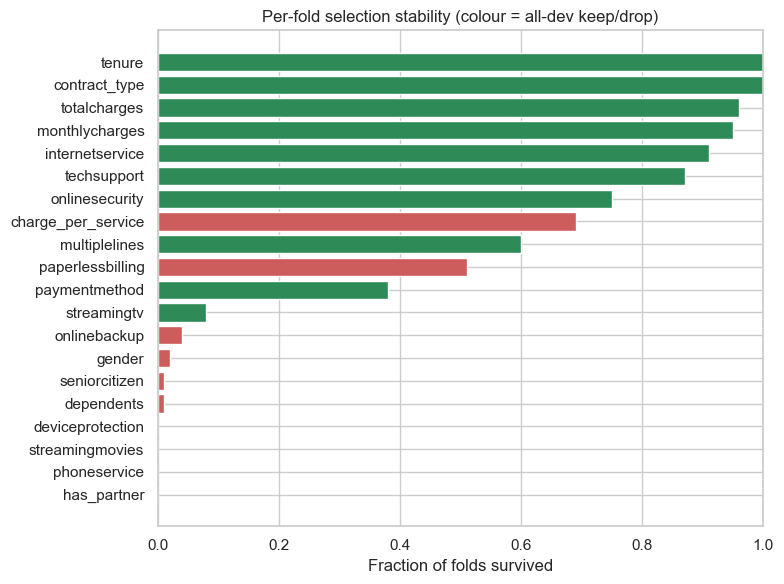

In [5]:
stability = pd.read_csv(f"{sel_dir}/per_fold_stability.csv").sort_values("stability")
fig, ax = plt.subplots(figsize=(8, 6))
colors = stability["feature"].isin(importance_table.loc[importance_table["survived"], "feature"]).map({True: "seagreen", False: "indianred"})
ax.barh(stability["feature"], stability["stability"], color=colors)
ax.set_xlabel("Fraction of folds survived")
ax.set_title("Per-fold selection stability (colour = all-dev keep/drop)")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

The per-fold check complicates the all-dev pick rather than confirming it cleanly: 8 of the 10 survivors are selected in at least 70 of 100 folds (`tenure`/`contract_type` every time), but `streamingtv` — the thinnest all-dev survivor (real importance 0.006 vs. a 0.005 floor) — is picked in only 5 of 100 folds, and `paymentmethod` in just 33. Two dropped features cross over the other way: `paperlessbilling` (55/100) and `charge_per_service` (46/100) are both selected more often than either `streamingtv` or `paymentmethod`, despite failing the all-dev floor outright. The all-dev fit and the per-fold vote genuinely disagree at the margin — expected, since these four features all sit close to the 0.005 floor, where a single fit's ranking is noisier than a 100-fold vote. This is exactly the scenario the aggregate paired-bootstrap test below — not this per-feature stability check — is built to resolve.

### Correlated group rescue checks

When features are highly correlated, permutation importance can split credit unevenly across them — starving one member below the decoy floor even though the group as a whole carries real signal. Two such groups exist in this feature set (per the heatmap and VIF check, §8a/§8b `01-eda.ipynb`): before dropping any member of either group, a group-level rescue check re-tests them together. Each group's correlation structure and rescue result is shown in its own subsection below.

In [6]:
print("Correlated groups checked:", DEFAULT_CORRELATED_GROUPS)

processed_path = get_project_root() / str(cfg.paths.processed_data) / "telco_churn_processed.csv"
df = pd.read_csv(processed_path)
dev_df, _test_df = partition(df)

Correlated groups checked: (('tenure', 'totalcharges', 'monthlycharges'), ('internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies'))


#### `tenure` / `totalcharges` / `monthlycharges`

`totalcharges` accrues from `monthlycharges` over `tenure` — the clearest linear dependency in the dataset.

feature,real_importance,importance_floor,survived,rescued
tenure,0.0880,0.0050,True,False
totalcharges,0.0240,0.0050,True,False
monthlycharges,0.0200,0.0050,True,False

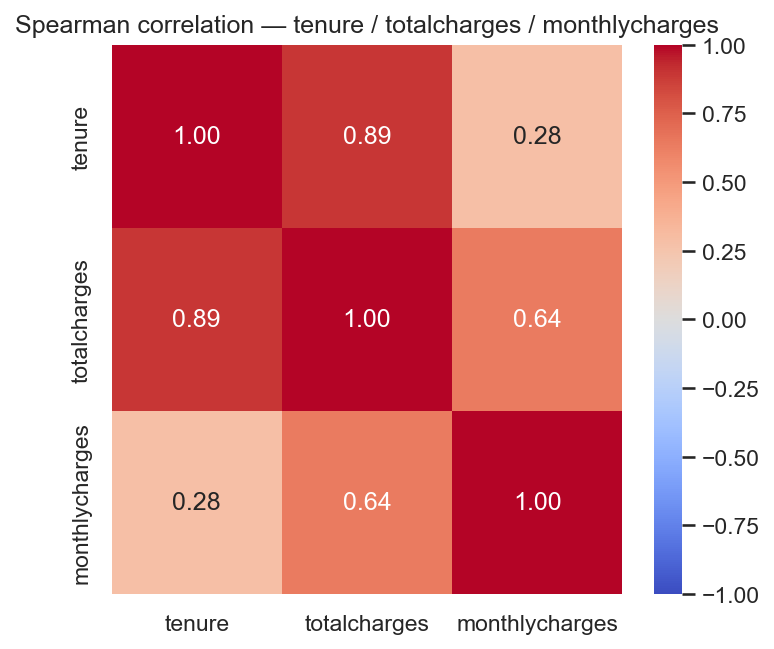

In [7]:
trio = list(DEFAULT_CORRELATED_GROUPS[0])
corr = dev_df[trio].corr(method="spearman")

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlation — tenure / totalcharges / monthlycharges")
plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
plt.close(fig)
trio_chart_b64 = base64.b64encode(buf.getvalue()).decode("ascii")

trio_table_html = (
    importance_table[importance_table["feature"].isin(trio)][
        ["feature", "real_importance", "importance_floor", "survived", "rescued"]
    ]
    .style.format({"real_importance": "{:.4f}", "importance_floor": "{:.4f}"})
    .hide(axis="index")
    .to_html()
)

HTML(
    '<div style="display:flex; align-items:flex-start; gap:24px; flex-wrap:wrap;">'
    f'<div style="flex:0 1 auto; min-width:300px;"><img src="data:image/png;base64,{trio_chart_b64}" style="max-width:100%;"></div>'
    f'<div style="flex:0 1 auto; min-width:260px; overflow:auto;">{trio_table_html}</div>'
    "</div>"
)

All three features individually clear the decoy floor despite `tenure` and `totalcharges` correlating at 0.89 — the strongest pair in the trio — so the rescue mechanism never needs to fire here. `monthlycharges` is the loosest link: it correlates only weakly with `tenure` (0.28), with `totalcharges` bridging the two rather than duplicating either.

#### `internetservice` add-on cluster

`internetservice_No` propagates identically across all six add-on columns (VIF = ∞, §8b `01-eda.ipynb`) whenever a customer has no internet service — a structural floor shared by all seven columns simultaneously.

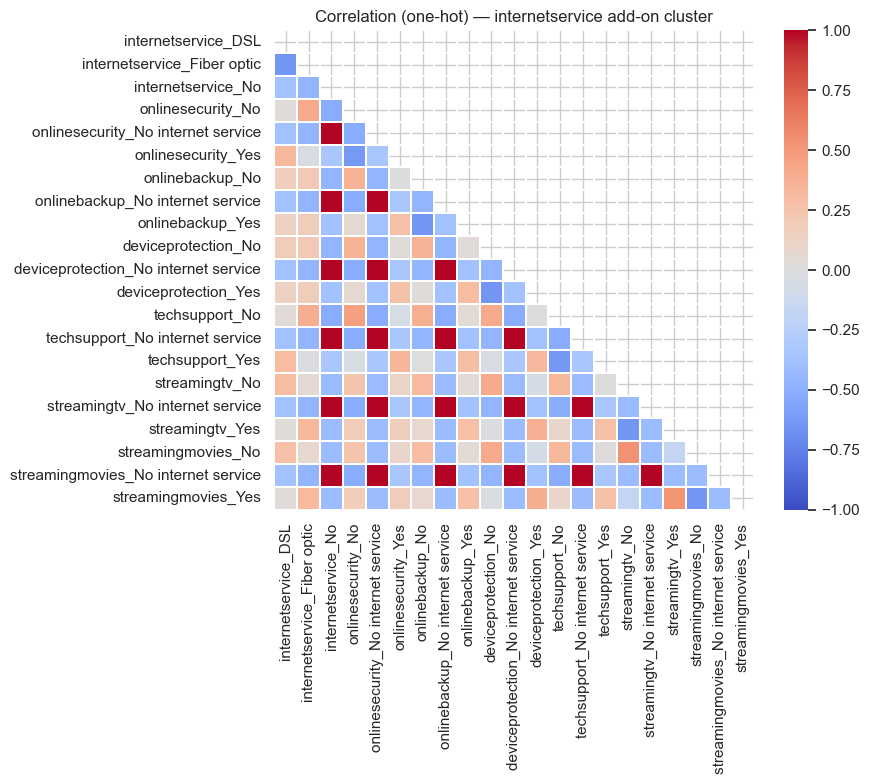

,feature,real_importance,importance_floor,survived,rescued
7,internetservice,0.028,0.005,True,False
11,techsupport,0.009,0.005,True,False
8,onlinesecurity,0.008,0.005,True,False
12,streamingtv,0.006,0.005,True,False
13,streamingmovies,0.004,0.005,False,False
9,onlinebackup,0.003,0.005,False,False
10,deviceprotection,-0.000,0.005,False,False


In [8]:
addon_group = list(DEFAULT_CORRELATED_GROUPS[1])
addon_corr = encoded_correlation_matrix(dev_df[addon_group], cat_cols=addon_group)

mask = np.triu(np.ones_like(addon_corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    addon_corr, mask=mask, cmap="coolwarm", center=0,
    vmin=-1, vmax=1, annot=False, linewidths=0.3, ax=ax
)
ax.set_title("Correlation (one-hot) — internetservice add-on cluster")
plt.tight_layout()
plt.show()

importance_table[importance_table["feature"].isin(addon_group)][
    ["feature", "real_importance", "importance_floor", "survived", "rescued"]
]

The heatmap confirms the structural artifact noted in §8b `01-eda.ipynb`: the `_No internet service` dummy on every add-on column is near-perfectly correlated with `internetservice_No` and with each other, since the same customers trigger all seven simultaneously. Despite that shared collinearity block, 4 of the 7 source features — `internetservice`, `onlinesecurity`, `techsupport`, `streamingtv` — individually clear the decoy floor. The other three (`onlinebackup`, `deviceprotection`, `streamingmovies`) fall short, but none needed rescuing: credit-splitting inside this cluster never dragged a real signal below the floor.

## 3. Full-set vs. reduced-set paired-bootstrap test

Does dropping to a smaller feature set cost PR-AUC, or is a leaner model just as good? Tested with a **paired bootstrap** on Δ = mean(AP_full) − mean(AP_reduced): each CV fold's full-feature score is paired against that same fold's reduced-feature score (identical `RepeatedStratifiedKFold` instance), which cancels intra-fold variance — more power than checking whether the reduced mean merely falls inside the full model's own *unpaired* CI. Same mechanism as the model-family decision (§3 `03a-model-selection.ipynb`). `run_selection_step` already computed and logged this test to MLflow; the cells below just render its result.

**Pre-registered decision rule** (materiality threshold Δ* = 0.005 PR-AUC — a real gap can still be too small to act on). The **reduced set is the default**: a leaner model wins unless the evidence says otherwise.

| Branch | Condition | Plain English | Outcome |
|---|---|---|---|
| `full_features_win` | CI excludes 0 in full's favour AND Δ ≥ Δ* | Dropping features costs real PR-AUC | Adopt the full set |
| `tie` | CI includes 0, or excludes 0 but $\lvert\Delta\rvert$ < Δ* | Can't tell them apart, or the gap is too small to matter | Adopt the reduced set (the simpler default) |
| `reduced_features_win` | CI excludes 0 in reduced's favour AND Δ ≤ -Δ* | The reduced set is actually better | Adopt the reduced set on the evidence |

Full-feature CV PR-AUC   : 0.6580  (mean of per-fold APs)
Reduced-feature CV PR-AUC: 0.6500  (mean of per-fold APs)
Paired Δ (full - reduced): 0.0080, 95% CI [0.0050, 0.0110], p=0.0000
Decision                 : full  (full_features_win)
Fold win rate            : full beats reduced on 69/100 folds (69%)


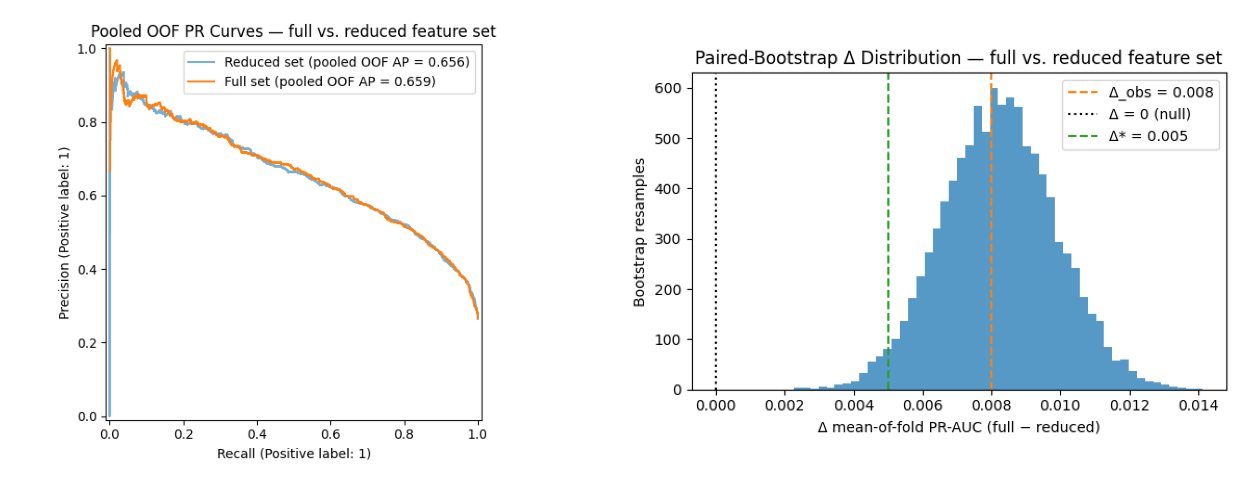

In [9]:
sel_metrics = client.get_run(run_ids["feature_selection"]).data.metrics
sel_params = client.get_run(run_ids["feature_selection"]).data.params

full_mean = sel_metrics["full_cv_pr_auc_mean"]
reduced_mean = sel_metrics["reduced_cv_pr_auc_mean"]
delta_obs = sel_metrics["bootstrap_delta_obs"]
delta_ci_lower = sel_metrics["bootstrap_delta_ci_lower"]
delta_ci_upper = sel_metrics["bootstrap_delta_ci_upper"]
p_value = sel_metrics["bootstrap_p_value"]
decision = sel_params["decision"]
decision_rule = sel_params["decision_rule"]

print(f"Full-feature CV PR-AUC   : {full_mean:.4f}  (mean of per-fold APs)")
print(f"Reduced-feature CV PR-AUC: {reduced_mean:.4f}  (mean of per-fold APs)")
print(f"Paired Δ (full - reduced): {delta_obs:.4f}, 95% CI [{delta_ci_lower:.4f}, {delta_ci_upper:.4f}], p={p_value:.4f}")
print(f"Decision                 : {decision}  ({decision_rule})")

# Companion diagnostic on the same paired folds: how often the full set's fold score
# beats the reduced set's, not just the average gap. Not part of the decision rule above.
full_folds = pd.Series(
    {h.step: h.value for h in client.get_metric_history(run_ids["lgbm_default"], "cv_pr_auc_fold")}
).sort_index()
reduced_folds = pd.Series(
    {h.step: h.value for h in client.get_metric_history(run_ids["feature_selection"], "reduced_cv_pr_auc_fold")}
).sort_index()
full_wins = int((full_folds > reduced_folds).sum())
win_rate = float((full_folds > reduced_folds).mean())
print(f"Fold win rate            : full beats reduced on {full_wins}/{len(full_folds)} folds ({win_rate:.0%})")

# Both artifacts logged on this same feature_selection run: OOF PR curves and the
# bootstrap-delta distribution the CI above was computed from.
pr_plot_path = mlflow.artifacts.download_artifacts(
    run_id=run_ids["feature_selection"], artifact_path="selection/pr_curves.png"
)
bs_plot_path = mlflow.artifacts.download_artifacts(
    run_id=run_ids["feature_selection"], artifact_path="selection/bootstrap_delta_dist.png"
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(plt.imread(pr_plot_path))
axes[0].axis("off")
axes[1].imshow(plt.imread(bs_plot_path))
axes[1].axis("off")
plt.tight_layout()
plt.show()

The CI `[+0.005, +0.011]` excludes zero entirely in the full set's favour, and the observed gap ($\Delta$ = 0.008) clears the materiality threshold ($\Delta^*$ = 0.005) — so `full_features_win` fires and the full set is adopted. This is a decisive win, not a coin flip: full beats reduced on 69 of 100 CV folds, so the same small edge repeats fold after fold rather than washing out under averaging.

The two plots use different, separately-logged metrics, not two readings of the same number: the PR curves (left, "pooled OOF AP") pool every fold's predictions before scoring once, which smooths away the fold-to-fold edge — the AP values (0.659 vs. 0.657) still show it, just muted. The bootstrap plot (right, "$\Delta$ mean-of-fold PR-AUC") scores each fold first and pairs full vs. reduced within that same fold before averaging, so the same repeating edge accumulates instead of washing out — that's the version the decision rule actually uses.

### Reasons for keeping the failed features

Per §7 `01-eda.ipynb`, most of the 10 features failing their own permutation-importance floor above do have real, statistically significant univariate correlation with churn — the add-on trio `onlinebackup`/`deviceprotection`/`streamingmovies` (Cramér's V 0.23–0.29), `paperlessbilling` (V = 0.19), and the protected-attribute trio `seniorcitizen`/`has_partner`/`dependents` (V = 0.15–0.16). That signal just doesn't survive as *marginal* contribution once the full feature set is already in the model — but it isn't a simple "redundant with one bigger feature" story: the add-on cluster's own rescue check above found no credit-splitting needed, and `seniorcitizen` barely correlates with any other feature in the dataset at all (a formal collinearity check gives it VIF ≈ 1.15, essentially independent — §8b `01-eda.ipynb`), so it isn't being crowded out by an overlapping feature either. `gender` and `phoneservice` are the cleaner case: EDA also found no real association for either (V ≈ 0.01, both fail to reject the null), so both tests agree there's no signal. `charge_per_service` is a different case again — an engineered feature with no §7 `01-eda.ipynb` citation to check against, since it didn't exist until it was constructed in LAP 7 of `02a-feature-discovery.ipynb`; it fails the decoy floor here despite passing a different, incremental-signal screen at adoption time (§3a `ANALYSIS.md`). `multiplelines` runs the other way — weak in EDA (V = 0.04), but still clears permutation importance here.

So why do any of these 10 stay in the model at all — including `gender` and `phoneservice`, which carry no signal by either measure? Because the decision above is a single yes/no choice between the full 20-feature set and the reduced 10-feature set, not a per-feature filter. Once the full set wins that aggregate test, every one of the 20 rides along together — there's no intermediate step that drops individually-null features on their own.

## 4. SHAP audit (diagnostic only)

Do the same features look important through a different lens? `compute_shap_audit` fits one final default-config LightGBM on the feature set the test above just froze and logs mean(|SHAP|) per feature — each feature's average contribution to individual predictions, not the performance drop from removing it. It's diagnostic only: permutation importance vs. the decoy floor and the paired-bootstrap test above are the only two things that decide keep/drop.

This audit is fit on the full feature set — which is also what shipped, since the full set won that test. Had the reduced set won instead, a second audit fit on just the committed features would appear here too, for direct comparison.

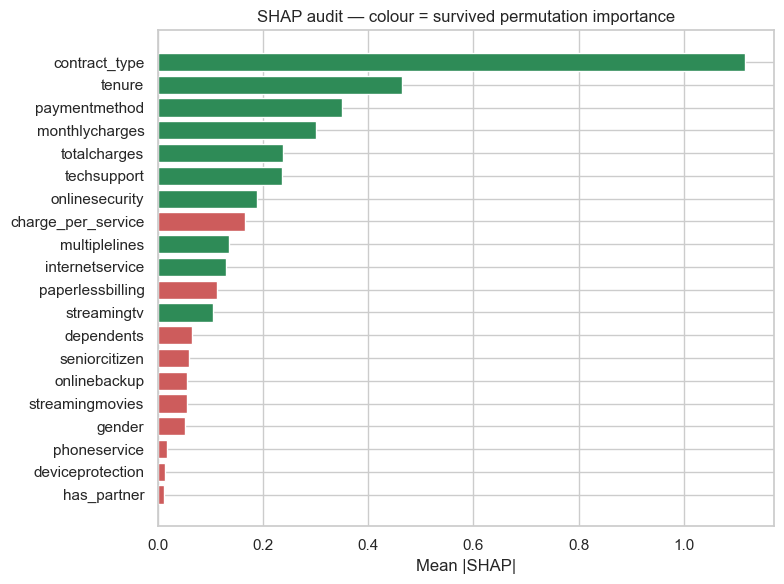

In [10]:
shap_audit = pd.read_csv(f"{sel_dir}/shap_importance_audit.csv")
shap_comparison = shap_audit.merge(
    importance_table[["feature", "survived"]], on="feature"
).sort_values("mean_abs_shap", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = shap_comparison["survived"].map({True: "seagreen", False: "indianred"})
ax.barh(shap_comparison["feature"], shap_comparison["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean |SHAP|")
ax.set_title("SHAP audit — colour = survived permutation importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The two signals mostly agree on *which* features matter, but not completely: 9 of the 10 permutation-importance survivors occupy 9 of the top 10 SHAP ranks. The exception is `streamingtv`, the thinnest survivor (real importance 0.006, barely above the 0.005 floor), which falls to 12th by SHAP (mean |SHAP| 0.105) — behind two features that failed the decoy floor outright: `charge_per_service` (8th, 0.167) and `paperlessbilling` (11th, 0.113). Among the features both signals agree on, ordering still reshuffles: `contract_type` and `tenure` swap the top two spots — SHAP credits `contract_type` more than twice tenure's share (1.12 vs. 0.47 mean |SHAP|), reversing permutation importance's order (0.084 vs. 0.088) — and `paymentmethod` jumps from a modest 7th-of-10 permutation-importance rank (0.013) to 3rd by SHAP, plausibly because SHAP credits its role in individual predictions more heavily than a single joint-shuffle drop captures. None of this changes anything downstream: this audit is diagnostic only — the paired-bootstrap test above, not any per-feature ranking, governs the keep/drop decision.

## Summary

This notebook renders the permutation-importance ranking against the decoy floor, the correlated-group rescue checks, the full-vs-reduced paired-bootstrap test, and the non-gating SHAP audit. Logic lives in `src/telco_churn/features/select.py` and `run_selection_step` (`src/telco_churn/models/train/feature_freeze.py`), which already ran and logged every result to MLflow; this notebook loads and renders those runs.

The paired-bootstrap test resolves `full_features_win`: the full set's PR-AUC edge over the reduced set is statistically real and large enough to act on, despite 10 of 20 features individually failing their own importance floor. The SHAP audit mostly agrees with permutation importance on which features matter, with one exception (`streamingtv` falls just outside the top SHAP ranks) — differences are otherwise limited to reordering within that set. The frozen (full) feature list is exported to `feature_columns.txt` on the `tuning_study` MLflow run — the input space for every stage downstream of this freeze. Full narrative: **[§4b Feature Selection (input-space freeze)](../ANALYSIS.md#4b-feature-selection-input-space-freeze)** in `ANALYSIS.md`. Continue to **`03c-hyperparameter-tuning.ipynb`**.